In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# Load a pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2') # Reimers and Gurevych, 2019

In [2]:
# Define your sentences
sentences = [
    "I like my phone",
    "Your cellphone looks great.",
    "Will it snow tomorrow?",
    "Hurricanes have hit the US",
    "How old are you?",
    "what is your age?"
]

# Encode sentences to get embeddings
embeddings = model.encode(sentences)

# Compute cosine similarity matrix
similarity_matrix = np.inner(embeddings, embeddings)

#print(similarity_matrix)

# Optionally, you can normalize the matrix to a 0-1 range
similarity_matrix = (similarity_matrix + 1) / 2

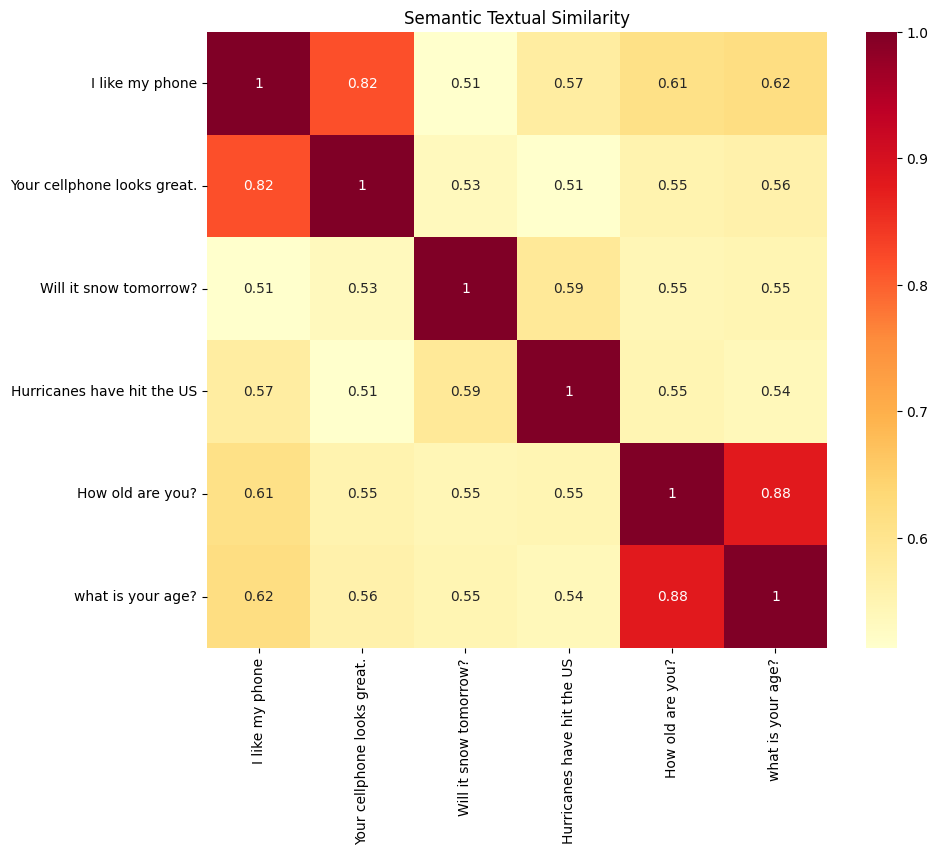

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='YlOrRd', xticklabels=sentences, yticklabels=sentences)
plt.title('Semantic Textual Similarity')
plt.show()

In [4]:
import pandas as pd
sentences = pd.read_csv("high-quality-english-sentences-train.csv")
sentences = sentences['text'].tolist()
print(f"Number of sentences: {len(sentences)}")

Number of sentences: 1534699


In [5]:
tenSentences = sentences[:10] # Limiting to 10 sentences for demonstration
tenSentences

['Soon we dropped into a living forest, where cold-tolerant evergreens and boreal animals still evoke the Canadian heritage of an ecosystem pushed south by glaciers 20,000 years ago.',
 'Annual population growth rate (2011 est., CIA World Factbook): 1.284%.',
 'This has led to the recent banning of Neonics in the EU, however the US and Canada are still using this chemical pesticide.',
 "In addition, these colors weren't confined to a province but rather irregularly scattered across various regions over all of China.",
 'A family member or a support person may stay with a patient during recovery.',
 'By the time emigrants got to what is now Nevada, they had been on the trail long enough that their supplies were down to just the basics.',
 "Advances in valve technology allow air cannons to operate with lower ... generation, coal, metal and .... installed on a cement plant's primary crusher.",
 'It stretched 363 miles across New York State from the Hudson River in the east to Lake Erie in

In [6]:
subset_sentences = sentences[:5]  # Limiting to 10 sentences for demonstration
subset_sentences

['Soon we dropped into a living forest, where cold-tolerant evergreens and boreal animals still evoke the Canadian heritage of an ecosystem pushed south by glaciers 20,000 years ago.',
 'Annual population growth rate (2011 est., CIA World Factbook): 1.284%.',
 'This has led to the recent banning of Neonics in the EU, however the US and Canada are still using this chemical pesticide.',
 "In addition, these colors weren't confined to a province but rather irregularly scattered across various regions over all of China.",
 'A family member or a support person may stay with a patient during recovery.']

## Similarity Matrix Structure

The similarity matrix would be organized as:

- Rows: Original English sentences (1 to n)
- Columns: Languages (Language 1, Language 2, Language 3, Language 4, Language 5)
- Cell values: Similarity score between the original sentence and its back-translation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def compute_similarity_matrix(model, original_sentences, back_translations_dict):
    # Get embeddings for original sentences
    original_embeddings = model.encode(original_sentences)
    
    # Initialize the similarity matrix
    # Rows = sentences, Columns = languages
    num_sentences = len(original_sentences)
    num_languages = len(back_translations_dict)
    print(num_sentences, num_languages)
    
    similarity_matrix = np.zeros((num_sentences, num_languages))

    
    # Calculate similarity for each language
    for lang_idx, (lang, translations) in enumerate(back_translations_dict.items()):
        # Get embeddings for back-translations
        back_translated_embeddings = model.encode(translations)
        
        # Calculate cosine similarity for each sentence pair
        for sent_idx in range(num_sentences):
            similarity = np.dot(original_embeddings[sent_idx], back_translated_embeddings[sent_idx]) / (
                np.linalg.norm(original_embeddings[sent_idx]) * np.linalg.norm(back_translated_embeddings[sent_idx])
            )
            similarity_matrix[sent_idx, lang_idx] = similarity
    
    return similarity_matrix

In [23]:
# Visualization function
def visualize_similarity_matrix(similarity_matrix, original_sentences, languages):
    # Create a DataFrame for better labeling
    df = pd.DataFrame(similarity_matrix, 
                     index=[f"Sentence {i}" for i in range(len(original_sentences))],
                     columns=languages)
    
    # Create heatmap
    ax = sns.heatmap(df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, 
                    linewidths=.5, cbar_kws={"label": "Similarity Score"})
    
    plt.title("Sentence Similarity: Original vs Back-Translations")
    plt.tight_layout()
    return plt

## Example

5 2


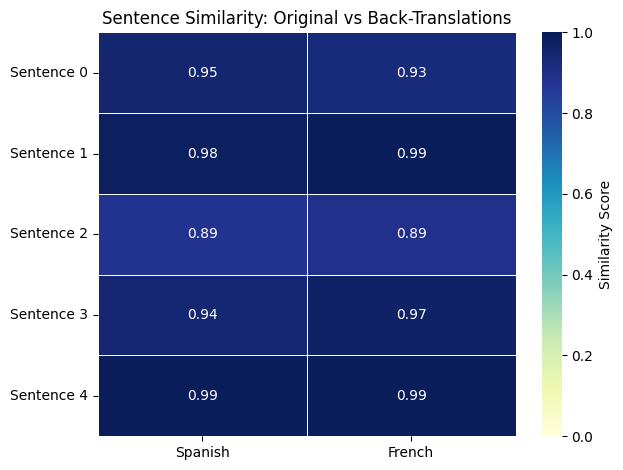

In [ ]:
original_english_sentences = ['Soon we dropped into a living forest, where cold-tolerant evergreens and boreal animals still evoke the Canadian heritage of an ecosystem pushed south by glaciers 20,000 years ago.',
 'Annual population growth rate (2011 est., CIA World Factbook): 1.284%.',
 'This has led to the recent banning of Neonics in the EU, however the US and Canada are still using this chemical pesticide.',
 "In addition, these colors weren't confined to a province but rather irregularly scattered across various regions over all of China.",
 'A family member or a support person may stay with a patient during recovery.']

# Example translations using google translate
translations={
    'Spanish': ["Pronto nos adentramos en un bosque vivo, donde los árboles de hoja perenne resistentes al frío y los animales boreales aún evocan la herencia canadiense de un ecosistema empujado hacia el sur por los glaciares hace 20.000 años.", 
                "Tasa de crecimiento poblacional anual (estimación de 2011, CIA World Factbook): 1,284%.", 
                "Esto ha llevado a la reciente prohibición de los neonicotinoides en la UE, aunque Estados Unidos y Canadá todavía siguen utilizando este pesticida químico.", 
                "Además, estos colores no estaban confinados a una provincia, sino que estaban dispersos irregularmente en varias regiones de toda China.",
                "Un miembro de la familia o una persona de apoyo puede quedarse con el paciente durante su recuperación."
                ],
    'French': ["Bientôt, nous sommes tombés dans une forêt vivante, où les conifères tolérants au froid et les animaux boréaux évoquent encore l'héritage canadien d'un écosystème poussé vers le sud par les glaciers il y a 20 000 ans.", 
            "Taux de croissance annuel de la population (estimation 2011, CIA World Factbook) : 1,284 %.", 
            "Cela a conduit à l’interdiction récente des néonicotinoïdes dans l’UE, mais les États-Unis et le Canada continuent d’utiliser ce pesticide chimique.",
            "De plus, ces couleurs n'étaient pas confinées à une province mais plutôt dispersées de manière irrégulière dans diverses régions de toute la Chine.", 
            "Un membre de la famille ou une personne de soutien peut rester avec le patient pendant sa convalescence."
            ]
} 

# Example back-translations using google translate
back_translations={
    'Spanish': ["We soon enter a living forest, where cold-hardy evergreens and boreal animals still evoke Canada's heritage of an ecosystem pushed south by glaciers 20,000 years ago.", 
                "Annual population growth rate (2011 estimate, CIA World Factbook): 1,284%.", 
                "This has led to the recent ban on neonicotinoids in the EU, although the United States and Canada still use this chemical pesticide.", 
                "Moreover, these colors were not confined to one province, but were scattered unevenly across various regions throughout China.",
                "A family member or support person may stay with the patient during recovery."
                ],
    'French': ["Soon we were in a living forest, where cold-tolerant conifers and boreal animals still evoke Canada's legacy of an ecosystem pushed south by glaciers 20,000 years ago.", 
            "Annual population growth rate (2011 estimate, CIA World Factbook): 1.284%.", 
            "This led to the recent ban of neonicotinoids in the EU, but the US and Canada continue to use this chemical pesticide.",
            "Moreover, these colors were not confined to one province but rather scattered irregularly in various regions throughout China.", 
            "A family member or support person may stay with the patient during recovery."
            ]
}

# Load a sentence embedding model
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

similarity_matrix = compute_similarity_matrix(model = model, original_sentences=original_english_sentences, back_translations_dict = back_translations)
plt = visualize_similarity_matrix(similarity_matrix, original_sentences=original_english_sentences, languages=back_translations.keys())
plt.show()